# 4. Personalidad — Evaluación cruzada (Benchmark)

En lugar de esperar a que el usuario califique películas, le pedimos que responda un **cuestionario de personalidad**, con eso obtenemos sus 5 rasgos **Big Five**:

1. **Openness** (Apertura) — curiosidad, creatividad, preferencia por lo novedoso
2. **Conscientiousness** (Responsabilidad) — organización, disciplina
3. **Extraversion** (Extraversión) — sociabilidad, búsqueda de estímulos
4. **Agreeableness** (Amabilidad) — cooperación, confianza
5. **Neuroticism** (Neuroticismo) — inestabilidad emocional, ansiedad

La idea es que la personalidad correlaciona con preferencias cinematográficas — una persona alta en Openness tiende a preferir cine de autor; una alta en Extraversion prefiere comedias y acción, etc.

## Modelo

**Tipo:** MLP de 3 capas. Deep Learning ligero, implementado en NumPy puro.

**Objetivo:** Aprender a convertir los 5 rasgos Big Five en un embedding de 64 dimensiones que viva en el **mismo espacio** que los item embeddings de LightGCN.

**Arquitectura:**
```
5 traits → [Linear(5, H) → ReLU → Dropout] → [Linear(H, H) → ReLU → Dropout] → Linear(H, 64) → user_embedding
```

**Predicción de score:**
```
score(u, i) = MLP(traits_u) · item_embedding[i] + bias_item[i]
```

- `MLP(traits_u)` = el embedding de usuario generado a partir de los 5 traits
- `item_embedding[i]` = embedding de la película, tomado de LightGCN (congelado, no se modifica)
- `bias_item[i]` = sesgo por película (se entrena junto con el MLP)
- El producto punto mide la afinidad entre la personalidad del usuario y la película

**En inferencia (cold-start):** Solo se necesitan los 5 traits del usuario nuevo. Se pasan por el MLP, se obtiene su embedding, y se calcula el producto punto contra todos los item embeddings para generar el ranking.

## Personalidades

- **Survey (~119 usuarios):** Tienen personalidad **real** medida con un cuestionario
- **Benchmark (~6,000 usuarios):** No respondieron cuestionario, así que se les **deriva** la personalidad a partir de sus ratings usando la **matriz de Nave et al. (2020)**. Esta matriz define, para cada género cinematográfico, qué puntaje promedio en cada rasgo Big Five tienen las personas que prefieren ese género. El pipeline: (1) calcular rating promedio por género por usuario, (2) softmax para normalizar, (3) multiplicar por la matriz de Nave → obtener los 5 traits estimados

## Evaluación cruzada 2×2

Se entrenan **dos variantes** del mismo modelo (mismo MLP, mismos item embeddings) y se evalúan en ambos datasets:

|                      | Evaluar Benchmark | Evaluar Survey    |
|----------------------|-------------------|-------------------|
| **Train: Benchmark** | PMLP_B → B        | PMLP_B → SV       |
| **Train: Survey**    | PMLP_SV → B       | PMLP_SV → SV      |

- **PMLP_B**: MLP entrenado con personalidades derivadas (6,000 usuarios, más datos pero menos precisos)
- **PMLP_SV**: MLP entrenado con personalidades reales IPIP (119 usuarios, menos datos pero más precisos)

La pregunta: ¿funciona mejor entrenar con muchos datos ruidosos o con pocos datos de alta calidad?

In [1]:
# Imports + paths
import itertools
import json
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from tabulate import tabulate
from tqdm.auto import tqdm

# ml config provides paths + helpers
sys.path.insert(0, str(Path.cwd().parent.parent))
import ml.config as cfg

from ml.evaluation import notebook_utils as nu
from ml.evaluation.metrics import ndcg_at_k, hit_rate_at_k
from ml.evaluation.splits import movielens_split, survey_split_sampled, _load_movie_matrix_map
from ml.models.lightgcn import LightGCN
from ml.models.personality import PersonalityMLPRecommender, TRAIT_COLS

K = 10
print(f'Benchmark data:')
print(f'  ratings: {cfg.RATINGS_PATH}')
print(f'  movies:  {cfg.MOVIES_PATH}')
print(f'  cosine:  {cfg.COSINE_SIM_PATH}')
print(f'  results: {cfg.RESULTS_DIR}')
print(f'Shared Survey data (from ml/):')
print(f'  ratings: {nu.RATINGS_SURVEY_PATH}')
print(f'  personalities: {nu._ML_DIR / "data" / "DataNewUsers" / "personalities.csv"}')


Benchmark data:
  ratings: /Users/dariozsh/Downloads/Final RS/ml/data/processed/ratings_benchmark.parquet
  movies:  /Users/dariozsh/Downloads/Final RS/ml/data/processed/movies_benchmark.csv
  cosine:  /Users/dariozsh/Downloads/Final RS/ml/data/processed/cosine_sim_benchmark.npy
  results: /Users/dariozsh/Downloads/Final RS/ml/results
Shared Survey data (from ml/):
  ratings: /Users/dariozsh/Downloads/Final RS/ml/data/DataNewUsers/ratings.csv
  personalities: /Users/dariozsh/Downloads/Final RS/ml/data/DataNewUsers/personalities.csv


In [ ]:
# ── Cargar benchmark ──────────────────────────────────────────────────
N_ITEMS = cfg.catalog_size()
cosine_sim = cfg.load_cosine_sim()
popularity = cfg.load_popularity()
ratings_bench = pd.read_parquet(cfg.RATINGS_PATH)
movies_bench = pd.read_csv(cfg.MOVIES_PATH)
print(f'Benchmark  ratings={len(ratings_bench):,}  users={ratings_bench["user_id"].nunique()}  items={N_ITEMS}')
print(f'cosine_sim shape: {cosine_sim.shape}')

# ── Splits ────────────────────────────────────────────────────────────
bench_train, bench_test = movielens_split(cfg.RATINGS_PATH)
print(f'Benchmark  train={len(bench_train):,}  test={len(bench_test):,}  users={bench_train["user_id"].nunique()}')

# Survey: compartido con ml/
sv_folds = survey_split_sampled(nu.RATINGS_SURVEY_PATH, cfg.MOVIES_PATH, n_negatives=99, seed=42)
print(f'Survey     folds={len(sv_folds):,}  (compartido con ml/)')

# Survey ratings ya tienen movie_id (0-based) alineado con movies_benchmark.csv
sv_raw = pd.read_csv(nu.RATINGS_SURVEY_PATH).rename(columns={'userid': 'user_id'})
sv_raw = sv_raw[sv_raw['movie_id'].notna()].copy()
sv_raw['movie_idx'] = sv_raw['movie_id'].astype(int)
sv_ratings_all = sv_raw[['user_id', 'movie_idx', 'rating']].reset_index(drop=True)
print(f'Survey ratings (en catálogo benchmark): {len(sv_ratings_all):,}  users={sv_ratings_all["user_id"].nunique()}')

In [ ]:
# ── Personalidades ────────────────────────────────────────────────────
# Benchmark: se leen del CSV pre-generado por notebook 8.
personalities_bench = pd.read_csv(cfg.DATA_DIR / 'personality_benchmark.csv')
print(f'Benchmark personalities: {len(personalities_bench):,} usuarios')
print(f'Trait stats:')
for c in TRAIT_COLS:
    print(f'  {c}: mean={personalities_bench[c].mean():.3f}  std={personalities_bench[c].std():.3f}')

# Survey personalities (shared from ml/)
personalities_sv = pd.read_csv(
    nu._ML_DIR / 'data' / 'DataNewUsers' / 'personalities.csv'
).rename(columns={'userid': 'user_id'})
print(f'\nSurvey personalities (IPIP real): {len(personalities_sv):,} usuarios')

## Fase 1 — Item embeddings compartidos (LightGCN sobre Benchmark)

Se entrena LightGCN sobre los ratings del benchmark para obtener **item embeddings de 64 dimensiones**. Estos embeddings se congelan y se comparten entre ambos modelos (PMLP_B y PMLP_SV) — el MLP solo aprende a mapear personalidad → este espacio.

In [4]:
print('Entrenando LightGCN sobre Benchmark (100 epochs)...')
t0 = time.time()
lgcn = LightGCN(n_factors=64, n_epochs=100, lr=0.005, reg=1e-4, n_layers=3, batch_size=4096)
lgcn.fit(bench_train)
print(f'LightGCN terminado en {time.time()-t0:.0f}s')

Ei_raw = lgcn._Ei_final
if Ei_raw.shape[0] < N_ITEMS:
    Ei = np.zeros((N_ITEMS, Ei_raw.shape[1]), dtype=np.float32)
    Ei[:Ei_raw.shape[0]] = Ei_raw
else:
    Ei = Ei_raw.astype(np.float32)
print(f'Item embeddings: {Ei.shape}')

Entrenando LightGCN sobre Benchmark (100 epochs)...
LightGCN terminado en 292s
Item embeddings: (3830, 64)


## Fase 2 — Búsqueda de hiperparámetros

Random search (12 trials) por separado para cada dataset. Se buscan los mejores valores de `hidden_dim`, `dropout`, `lr`, `weight_decay` y `n_epochs`. Los datasets son muy distintos en tamaño (6,000 vs 119 usuarios), por lo que los óptimos pueden diferir.

In [5]:
# ── Helpers ──────────────────────────────────────────────────────────
def eval_ndcg_subset(model, val_df, k, subset):
    rpu = val_df[val_df['rating'] >= 4.0].groupby('user_id')['movie_idx'].apply(set).to_dict()
    sc = []
    for u in subset:
        r = rpu.get(int(u))
        if not r: continue
        recs = model.recommend(int(u), n=k)
        if not recs: continue
        sc.append(ndcg_at_k(recs, r, k))
    return float(np.mean(sc)) if sc else 0.0

PMLP_GRID = {
    'hidden_dim':   [64, 128],
    'dropout':      [0.2, 0.3, 0.5],
    'lr':           [5e-4, 1e-3],
    'weight_decay': [1e-5, 1e-4],
    'n_epochs':     [20, 30],
}
keys = list(PMLP_GRID.keys())

def sample_trials(seed, n_trials=12):
    rng_hp = random.Random(seed)
    trials, seen_combos = [], set()
    while len(trials) < n_trials:
        combo = tuple(rng_hp.choice(PMLP_GRID[k]) for k in keys)
        if combo not in seen_combos:
            seen_combos.add(combo)
            trials.append(combo)
    return trials

### 2.1 Tuning PMLP_B (sobre Benchmark)

Se entrena el MLP usando personalidades **derivadas** de los 6,000 usuarios del benchmark. Validación: NDCG@10 full-catalog sobre 500 usuarios aleatorios.

In [6]:
# ── Inner-val sobre Benchmark ────────────────────────────────────────
RNG = np.random.default_rng(42)
_shuf = bench_train.sample(frac=1, random_state=42).reset_index(drop=True)
_cut = int(len(_shuf) * 0.9)
inner_train_b = _shuf.iloc[:_cut].reset_index(drop=True)
inner_val_b = _shuf.iloc[_cut:].reset_index(drop=True)
_elig = inner_val_b[inner_val_b['rating'] >= 4.0]['user_id'].unique()
SUBSET_B = RNG.choice(_elig, size=min(300, len(_elig)), replace=False)
print(f'Inner-val B: train={len(inner_train_b):,}  val={len(inner_val_b):,}  subset={len(SUBSET_B)}')

trials_b = sample_trials(seed=42)
b_results = []
for combo in tqdm(trials_b, desc='PMLP_B tuning'):
    cfg_d = dict(zip(keys, combo))
    t0 = time.time()
    m = PersonalityMLPRecommender(
        personalities=personalities_bench, cf_item_embeddings=Ei,
        embedding_dim=64, batch_size=1024, patience=3, seed=42,
        normalize_items=True, popularity_penalty=1.0,
        mmr_lambda=0.5, cosine_sim=cosine_sim, **cfg_d,
    )
    m.fit(inner_train_b)
    ndcg = eval_ndcg_subset(m, inner_val_b, K, SUBSET_B)
    b_results.append({**cfg_d, 'ndcg': ndcg, 'time_s': round(time.time()-t0, 1)})

b_df = pd.DataFrame(b_results).sort_values('ndcg', ascending=False).reset_index(drop=True)
best_cfg_b = {k: b_df.iloc[0][k] for k in keys}
for k in ['hidden_dim', 'n_epochs']: best_cfg_b[k] = int(best_cfg_b[k])
for k in ['dropout', 'lr', 'weight_decay']: best_cfg_b[k] = float(best_cfg_b[k])

display(Markdown('#### Mejor configuración PMLP_B'))
print(tabulate([[k, v] for k, v in best_cfg_b.items()],
               headers=['Parámetro', 'Valor'], tablefmt='fancy_grid'))
print(f'\nNDCG@{K} validación = {b_df.iloc[0]["ndcg"]:.4f}')

# cfg.RESULTS_DIR.mkdir(exist_ok=True)
# with open(cfg.RESULTS_DIR / 'pmlp_b_tuning.json', 'w') as f:
#     json.dump(b_df.to_dict(orient='records'), f, indent=2)

Inner-val B: train=718,028  val=79,781  subset=300


PMLP_B tuning:   0%|          | 0/12 [00:00<?, ?it/s]

#### Mejor configuración PMLP_B

╒══════════════╤═════════╕
│ Parámetro    │   Valor │
╞══════════════╪═════════╡
│ hidden_dim   │ 128     │
├──────────────┼─────────┤
│ dropout      │   0.5   │
├──────────────┼─────────┤
│ lr           │   0.001 │
├──────────────┼─────────┤
│ weight_decay │   1e-05 │
├──────────────┼─────────┤
│ n_epochs     │  20     │
╘══════════════╧═════════╛

NDCG@10 validación = 0.1333


### 2.2 Tuning PMLP_SV (sobre Survey)

Se entrena el MLP usando personalidades **reales** (IPIP) de los ~119 usuarios del Survey. Validación: NDCG@10 sobre el train de Survey con LOO interno.

In [7]:
# ── Inner-val sobre Survey ───────────────────────────────────────────
_sv_shuf = sv_ratings_all.sample(frac=1, random_state=42).reset_index(drop=True)
_sv_cut = int(len(_sv_shuf) * 0.9)
inner_train_sv = _sv_shuf.iloc[:_sv_cut].reset_index(drop=True)
inner_val_sv = _sv_shuf.iloc[_sv_cut:].reset_index(drop=True)
_elig_sv = inner_val_sv[inner_val_sv['rating'] >= 4.0]['user_id'].unique()
SUBSET_SV = _elig_sv  # usar todos (son pocos)
print(f'Inner-val SV: train={len(inner_train_sv):,}  val={len(inner_val_sv):,}  subset={len(SUBSET_SV)}')

trials_sv = sample_trials(seed=43)
sv_results = []
for combo in tqdm(trials_sv, desc='PMLP_SV tuning'):
    cfg_d = dict(zip(keys, combo))
    t0 = time.time()
    m = PersonalityMLPRecommender(
        personalities=personalities_sv, cf_item_embeddings=Ei,
        embedding_dim=64, batch_size=256, patience=3, seed=42,
        normalize_items=True, popularity_penalty=1.0,
        mmr_lambda=0.5, cosine_sim=cosine_sim, **cfg_d,
    )
    m.fit(inner_train_sv)
    ndcg = eval_ndcg_subset(m, inner_val_sv, K, SUBSET_SV)
    sv_results.append({**cfg_d, 'ndcg': ndcg, 'time_s': round(time.time()-t0, 1)})

sv_df = pd.DataFrame(sv_results).sort_values('ndcg', ascending=False).reset_index(drop=True)
best_cfg_sv = {k: sv_df.iloc[0][k] for k in keys}
for k in ['hidden_dim', 'n_epochs']: best_cfg_sv[k] = int(best_cfg_sv[k])
for k in ['dropout', 'lr', 'weight_decay']: best_cfg_sv[k] = float(best_cfg_sv[k])

display(Markdown('#### Mejor configuración PMLP_SV'))
print(tabulate([[k, v] for k, v in best_cfg_sv.items()],
               headers=['Parámetro', 'Valor'], tablefmt='fancy_grid'))
print(f'\nNDCG@{K} validación = {sv_df.iloc[0]["ndcg"]:.4f}')

# with open(cfg.RESULTS_DIR / 'pmlp_sv_tuning.json', 'w') as f:
#     json.dump(sv_df.to_dict(orient='records'), f, indent=2)

Inner-val SV: train=2,547  val=283  subset=89


PMLP_SV tuning:   0%|          | 0/12 [00:00<?, ?it/s]

#### Mejor configuración PMLP_SV

╒══════════════╤═════════╕
│ Parámetro    │   Valor │
╞══════════════╪═════════╡
│ hidden_dim   │ 64      │
├──────────────┼─────────┤
│ dropout      │  0.3    │
├──────────────┼─────────┤
│ lr           │  0.0005 │
├──────────────┼─────────┤
│ weight_decay │  0.0001 │
├──────────────┼─────────┤
│ n_epochs     │ 30      │
╘══════════════╧═════════╛

NDCG@10 validación = 0.0000


## Fase 3 — Entrenamiento final de los dos modelos

Cada modelo se entrena una sola vez sobre **todo** el train de su dataset con los mejores hiperparámetros encontrados. Ambos comparten los mismos item embeddings de LightGCN.

In [8]:
# ── PMLP_B: train sobre Benchmark completo ──────────────────────────
print('Entrenando PMLP_B...')
t0 = time.time()
pmlp_b = PersonalityMLPRecommender(
    personalities=personalities_bench, cf_item_embeddings=Ei,
    embedding_dim=64, batch_size=1024, patience=5, seed=42,
    normalize_items=True, popularity_penalty=1.0,
    mmr_lambda=0.5, cosine_sim=cosine_sim, **best_cfg_b,
)
pmlp_b.fit(bench_train)
print(f'PMLP_B entrenado en {time.time()-t0:.0f}s')

# ── PMLP_SV: train sobre Survey completo ────────────────────────────
print('\nEntrenando PMLP_SV...')
t0 = time.time()
pmlp_sv = PersonalityMLPRecommender(
    personalities=personalities_sv, cf_item_embeddings=Ei,
    embedding_dim=64, batch_size=256, patience=5, seed=42,
    normalize_items=True, popularity_penalty=1.0,
    mmr_lambda=0.5, cosine_sim=cosine_sim, **best_cfg_sv,
)
pmlp_sv.fit(sv_ratings_all)
print(f'PMLP_SV entrenado en {time.time()-t0:.0f}s')

Entrenando PMLP_B...
PMLP_B entrenado en 44s

Entrenando PMLP_SV...
PMLP_SV entrenado en 0s


## Fase 4 — Evaluación matriz 2×2

Cada modelo se evalúa en ambos datasets **sin re-entrenar**. Para evaluar en el otro dataset, se usa `set_personalities()` para intercambiar los rasgos de entrada — el MLP y los item embeddings permanecen fijos.

- **Benchmark:** full-catalog (6 métricas: Precision, Recall, NDCG, Diversity, Novelty, Coverage)
- **Survey:** sampled LOO con 99 negativos (HR@10, NDCG@10)

In [9]:
# ── Helper para Survey sin refit ─────────────────────────────────────
def evaluate_survey_no_refit(model, folds, k, n_items):
    hr_list, ndcg_list, skipped = [], [], 0
    for _train, test, candidates in folds:
        uid = int(test['user_id'].iloc[0])
        positive = int(test['movie_idx'].iloc[0])
        scores = model.score_all(uid)
        if scores is None:
            skipped += 1
            continue
        if scores.shape[0] < n_items:
            padded = np.full(n_items, -np.inf, dtype=np.float32)
            padded[: scores.shape[0]] = scores
            scores = padded
        cand_scores = scores[candidates]
        ranked = candidates[np.argsort(-cand_scores)].tolist()
        relevant = {positive}
        hr_list.append(hit_rate_at_k(ranked, relevant, k))
        ndcg_list.append(ndcg_at_k(ranked, relevant, k))
    return {
        'hr': float(np.mean(hr_list)) if hr_list else 0.0,
        'ndcg': float(np.mean(ndcg_list)) if ndcg_list else 0.0,
        'n_evaluated': len(hr_list),
        'n_skipped': skipped,
    }

### Celda (1) — PMLP_B → Benchmark (full-catalog)

Modelo entrenado con personalidades derivadas, evaluado sobre el mismo dataset de benchmark.

In [10]:
res_b_b = nu.evaluate_movielens(
    model=pmlp_b, train=bench_train, test=bench_test, k=K,
    cosine_sim=cosine_sim, popularity=popularity, n_items=N_ITEMS,
)
display(Markdown(f'**(1) PMLP_B → Benchmark (K={K})**'))
nu.print_metrics(res_b_b)

**(1) PMLP_B → Benchmark (K=10)**

╒═════════════╤══════════╕
│ Métrica     │    Valor │
╞═════════════╪══════════╡
│ precision   │    0.209 │
├─────────────┼──────────┤
│ recall      │    0.221 │
├─────────────┼──────────┤
│ ndcg        │    0.249 │
├─────────────┼──────────┤
│ diversity   │    0.432 │
├─────────────┼──────────┤
│ novelty     │    0.27  │
├─────────────┼──────────┤
│ coverage    │    0.043 │
├─────────────┼──────────┤
│ n_evaluated │ 5987     │
├─────────────┼──────────┤
│ n_skipped   │    0     │
╘═════════════╧══════════╛


### Celda (2) — PMLP_B → Survey (sampled LOO)

Modelo entrenado con personalidades derivadas, pero evaluado con personalidades reales del Survey. Mide si lo aprendido con datos derivados generaliza a rasgos IPIP reales.

In [11]:
# PMLP_B entrenado con personalidades del benchmark. Para evaluar en Survey,
# inyectamos las personalidades del Survey (el MLP aprendido se aplica al
# nuevo input).
pmlp_b.set_personalities(personalities_sv)
res_b_sv = evaluate_survey_no_refit(pmlp_b, sv_folds, K, N_ITEMS)
display(Markdown(f'**(2) PMLP_B → Survey (K={K})**'))
nu.print_metrics(res_b_sv)

# Restaurar personalidades originales
pmlp_b.set_personalities(personalities_bench)

**(2) PMLP_B → Survey (K=10)**

╒═════════════╤═════════╕
│ Métrica     │   Valor │
╞═════════════╪═════════╡
│ hr          │   0.763 │
├─────────────┼─────────┤
│ ndcg        │   0.494 │
├─────────────┼─────────┤
│ n_evaluated │ 118     │
├─────────────┼─────────┤
│ n_skipped   │   0     │
╘═════════════╧═════════╛


### Celda (3) — PMLP_SV → Benchmark (full-catalog)

Modelo entrenado con personalidades reales del Survey, evaluado con personalidades derivadas del benchmark. Mide si lo aprendido con pocos usuarios reales generaliza a miles de usuarios derivados.

In [12]:
# PMLP_SV entrenado con personalidades del Survey. Para evaluar en Benchmark,
# inyectamos las personalidades del benchmark y poblamos user_seen desde
# bench_train (para suprimir ítems ya vistos).
pmlp_sv.set_personalities(personalities_bench)
pmlp_sv._user_seen = {}
for uid, mid in zip(bench_train['user_id'].values, bench_train['movie_idx'].values):
    pmlp_sv._user_seen.setdefault(int(uid), set()).add(int(mid))

res_sv_b = nu.evaluate_movielens(
    model=pmlp_sv, train=bench_train, test=bench_test, k=K,
    cosine_sim=cosine_sim, popularity=popularity, n_items=N_ITEMS,
)
display(Markdown(f'**(3) PMLP_SV → Benchmark (K={K})**'))
nu.print_metrics(res_sv_b)

# Restaurar personalidades originales
pmlp_sv.set_personalities(personalities_sv)

**(3) PMLP_SV → Benchmark (K=10)**

╒═════════════╤══════════╕
│ Métrica     │    Valor │
╞═════════════╪══════════╡
│ precision   │    0.201 │
├─────────────┼──────────┤
│ recall      │    0.212 │
├─────────────┼──────────┤
│ ndcg        │    0.237 │
├─────────────┼──────────┤
│ diversity   │    0.435 │
├─────────────┼──────────┤
│ novelty     │    0.28  │
├─────────────┼──────────┤
│ coverage    │    0.048 │
├─────────────┼──────────┤
│ n_evaluated │ 5987     │
├─────────────┼──────────┤
│ n_skipped   │    0     │
╘═════════════╧══════════╛


### Celda (4) — PMLP_SV → Survey (sampled LOO)

Modelo entrenado y evaluado sobre el mismo dataset de Survey (personalidades reales).

In [13]:
res_sv_sv = evaluate_survey_no_refit(pmlp_sv, sv_folds, K, N_ITEMS)
display(Markdown(f'**(4) PMLP_SV → Survey (K={K})**'))
nu.print_metrics(res_sv_sv)

**(4) PMLP_SV → Survey (K=10)**

╒═════════════╤═════════╕
│ Métrica     │   Valor │
╞═════════════╪═════════╡
│ hr          │   0.729 │
├─────────────┼─────────┤
│ ndcg        │   0.454 │
├─────────────┼─────────┤
│ n_evaluated │ 118     │
├─────────────┼─────────┤
│ n_skipped   │   0     │
╘═════════════╧═════════╛


## Fase 5 — Resumen matriz 2×2

Tabla consolidada con los 4 resultados. Permite comparar directamente si entrenar con más datos (derivados) o con datos más precisos (IPIP) produce mejores recomendaciones.

In [14]:
# ── NDCG@10 en matriz 2×2 ─────────────────────────────────────────────
display(Markdown(f'### NDCG@{K} — matriz 2×2'))
matrix = [
    ['Train Benchmark', f'{res_b_b["ndcg"]:.4f}',  f'{res_b_sv["ndcg"]:.4f}'],
    ['Train Survey',    f'{res_sv_b["ndcg"]:.4f}', f'{res_sv_sv["ndcg"]:.4f}'],
]
print(tabulate(matrix, headers=['', 'Eval Benchmark', 'Eval Survey'], tablefmt='fancy_grid'))

# ── Detalle Benchmark (6 métricas) ─────────────────────────────────────
bench_keys = ['precision', 'recall', 'ndcg', 'diversity', 'novelty', 'coverage']
bench_labels = [f'Precision@{K}', f'Recall@{K}', f'NDCG@{K}', f'Diversity@{K}', f'Novelty@{K}', 'Coverage']
display(Markdown('\n### Benchmark (6 métricas full-catalog)'))
rows = [[label, f'{res_b_b[k]:.4f}', f'{res_sv_b[k]:.4f}']
        for k, label in zip(bench_keys, bench_labels)]
print(tabulate(rows, headers=['Métrica', 'PMLP_B', 'PMLP_SV'], tablefmt='fancy_grid'))

# ── Detalle Survey ─────────────────────────────────────────────────────
display(Markdown('\n### Survey (sampled LOO con 99 negativos)'))
sv_rows = [
    [f'HR@{K}',   f'{res_b_sv["hr"]:.4f}',   f'{res_sv_sv["hr"]:.4f}'],
    [f'NDCG@{K}', f'{res_b_sv["ndcg"]:.4f}', f'{res_sv_sv["ndcg"]:.4f}'],
]
print(tabulate(sv_rows, headers=['Métrica', 'PMLP_B', 'PMLP_SV'], tablefmt='fancy_grid'))

### NDCG@10 — matriz 2×2

╒═════════════════╤══════════════════╤═══════════════╕
│                 │   Eval Benchmark │   Eval Survey │
╞═════════════════╪══════════════════╪═══════════════╡
│ Train Benchmark │           0.2491 │        0.4937 │
├─────────────────┼──────────────────┼───────────────┤
│ Train Survey    │           0.2371 │        0.4535 │
╘═════════════════╧══════════════════╧═══════════════╛



### Benchmark (6 métricas full-catalog)

╒══════════════╤══════════╤═══════════╕
│ Métrica      │   PMLP_B │   PMLP_SV │
╞══════════════╪══════════╪═══════════╡
│ Precision@10 │   0.2092 │    0.2009 │
├──────────────┼──────────┼───────────┤
│ Recall@10    │   0.2209 │    0.2119 │
├──────────────┼──────────┼───────────┤
│ NDCG@10      │   0.2491 │    0.2371 │
├──────────────┼──────────┼───────────┤
│ Diversity@10 │   0.4315 │    0.4352 │
├──────────────┼──────────┼───────────┤
│ Novelty@10   │   0.27   │    0.2799 │
├──────────────┼──────────┼───────────┤
│ Coverage     │   0.0428 │    0.0483 │
╘══════════════╧══════════╧═══════════╛



### Survey (sampled LOO con 99 negativos)

╒═══════════╤══════════╤═══════════╕
│ Métrica   │   PMLP_B │   PMLP_SV │
╞═══════════╪══════════╪═══════════╡
│ HR@10     │   0.7627 │    0.7288 │
├───────────┼──────────┼───────────┤
│ NDCG@10   │   0.4937 │    0.4535 │
╘═══════════╧══════════╧═══════════╛


## Fase 6 — Visualización

Gráficas comparativas: cada panel muestra las métricas de ambos modelos (PMLP_B vs PMLP_SV) lado a lado.

### PMLP_B (entrenado en Benchmark)

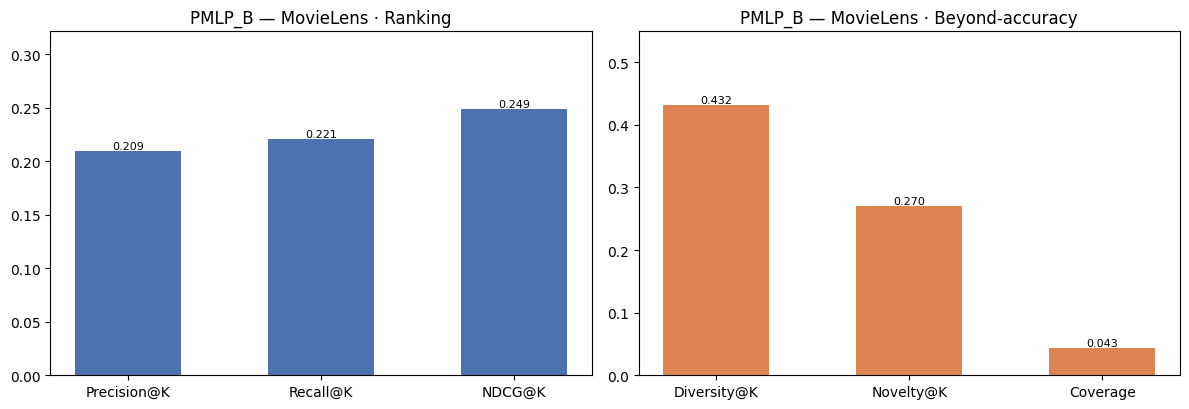

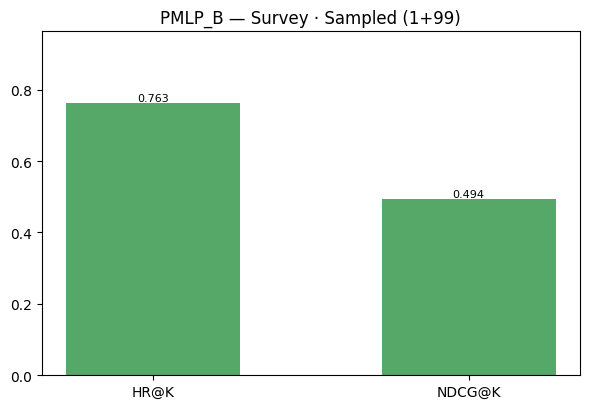

### PMLP_SV (entrenado en Survey)

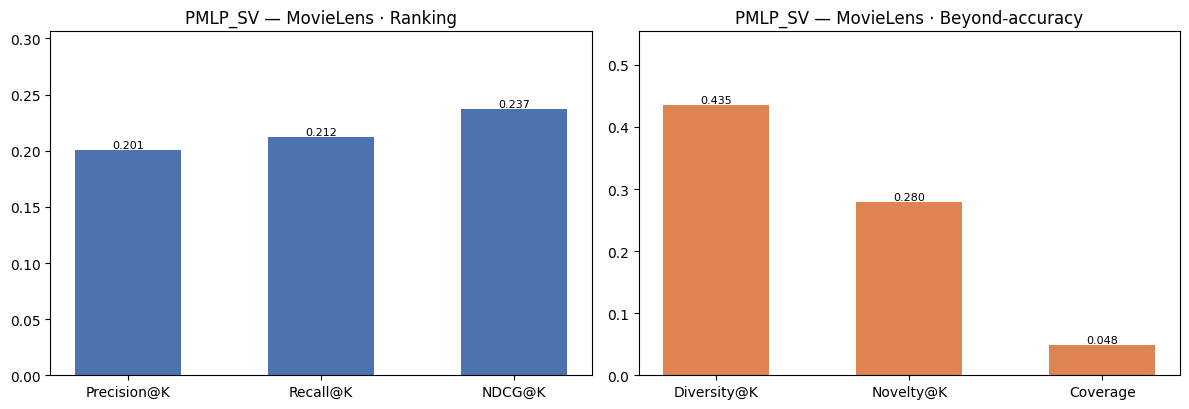

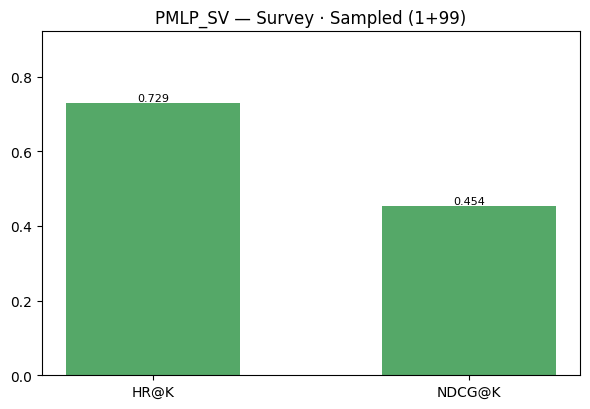

In [15]:
display(Markdown('### PMLP_B (entrenado en Benchmark)'))
nu.plot_dataset_metrics(
    movielens=res_b_b, survey=res_b_sv,
    title_prefix='PMLP_B — ',
)

display(Markdown('### PMLP_SV (entrenado en Survey)'))
nu.plot_dataset_metrics(
    movielens=res_sv_b, survey=res_sv_sv,
    title_prefix='PMLP_SV — ',
)

## Fase 7 — Ejemplos cold-start

Se muestran recomendaciones para usuarios sin historial — solo usando sus 5 rasgos Big Five como input. 3 usuarios del Benchmark (personalidad derivada) y 2 del Survey (personalidad real IPIP), cada uno con las recomendaciones de ambos modelos.

In [16]:
TRAIT_LABELS_ES = {
    'openness':          'Apertura',
    'conscientiousness': 'Responsabilidad',
    'extraversion':      'Extraversión',
    'agreeableness':     'Amabilidad',
    'neuroticism':       'Neuroticismo',
}

lookup = {int(r.movie_id): (r.title, str(r.release_date)[:4] if pd.notna(r.release_date) else '—')
          for r in movies_bench.itertuples(index=False)}

def show_row(label, recs, scores, k=10):
    rows = []
    for rank, idx in enumerate(recs[:k], start=1):
        title, year = lookup.get(int(idx), (f'<idx {idx}>', '—'))
        s = float(scores[int(idx)]) if scores is not None and int(idx) < len(scores) else float('nan')
        rows.append([rank, title, year, f'{s:.3f}'])
    display(Markdown(f'**{label}**'))
    print(tabulate(rows, headers=['#', 'Título', 'Año', 'Score'], tablefmt='fancy_grid'))

def show_user_both_models(uid, source_label, pers_df):
    display(Markdown(f'## Usuario {uid} ({source_label})'))
    pers_idx = pers_df.set_index('user_id')
    if uid not in pers_idx.index:
        display(Markdown('_Sin personalidad registrada_'))
        return
    row = pers_idx.loc[uid]
    trait_rows = [[TRAIT_LABELS_ES[c], f'{float(row[c]):.3f}'] for c in TRAIT_COLS]
    display(Markdown('**Perfil Big Five:**'))
    print(tabulate(trait_rows, headers=['Rasgo', 'Valor'], tablefmt='fancy_grid'))

    # Inyectar personalidad del usuario en ambos modelos
    pmlp_b.set_personalities(pers_df)
    pmlp_sv.set_personalities(pers_df)

    recs_b = pmlp_b.recommend(uid, n=10)
    s_b = pmlp_b.score_all(uid)
    if recs_b:
        show_row('Top-10 recomendaciones PMLP_B:', recs_b, s_b)

    recs_sv = pmlp_sv.recommend(uid, n=10)
    s_sv = pmlp_sv.score_all(uid)
    if recs_sv:
        show_row('Top-10 recomendaciones PMLP_SV:', recs_sv, s_sv)

# Picks: 3 usuarios del Benchmark + 2 del Survey
rng_pick = np.random.default_rng(42)
bench_uids = personalities_bench['user_id'].unique()
sv_uids = personalities_sv['user_id'].unique()
picks_b = rng_pick.choice(bench_uids, size=3, replace=False)
picks_sv = rng_pick.choice(sv_uids, size=2, replace=False)

for uid in picks_b:
    show_user_both_models(int(uid), 'de Benchmark', personalities_bench)

for uid in picks_sv:
    show_user_both_models(int(uid), 'de Survey', personalities_sv)

# Restaurar estado
pmlp_b.set_personalities(personalities_bench)
pmlp_sv.set_personalities(personalities_sv)

## Usuario 3927 (de Benchmark)

**Perfil Big Five:**

╒═════════════════╤═════════╕
│ Rasgo           │   Valor │
╞═════════════════╪═════════╡
│ Apertura        │   4.544 │
├─────────────────┼─────────┤
│ Responsabilidad │   2.97  │
├─────────────────┼─────────┤
│ Extraversión    │   1.768 │
├─────────────────┼─────────┤
│ Amabilidad      │   3.101 │
├─────────────────┼─────────┤
│ Neuroticismo    │   2.693 │
╘═════════════════╧═════════╛


**Top-10 recomendaciones PMLP_B:**

╒═════╤═══════════════════════════════════════════════════╤═══════╤═════════╕
│   # │ Título                                            │   Año │   Score │
╞═════╪═══════════════════════════════════════════════════╪═══════╪═════════╡
│   1 │ Monsters, Inc.                                    │  2001 │   3.328 │
├─────┼───────────────────────────────────────────────────┼───────┼─────────┤
│   2 │ The Lord of the Rings: The Fellowship of the Ring │  2001 │   3.205 │
├─────┼───────────────────────────────────────────────────┼───────┼─────────┤
│   3 │ How to Train Your Dragon                          │  2010 │   3.243 │
├─────┼───────────────────────────────────────────────────┼───────┼─────────┤
│   4 │ Mulan                                             │  1998 │   3.18  │
├─────┼───────────────────────────────────────────────────┼───────┼─────────┤
│   5 │ Toy Story 2                                       │  1999 │   3.206 │
├─────┼───────────────────────────────────────────────────┼─────

...

╒═════════════════╤═════════╕
│ Rasgo           │   Valor │
╞═════════════════╪═════════╡
│ Apertura        │    4    │
├─────────────────┼─────────┤
│ Responsabilidad │    2.33 │
├─────────────────┼─────────┤
│ Extraversión    │    4    │
├─────────────────┼─────────┤
│ Amabilidad      │    2.67 │
├─────────────────┼─────────┤
│ Neuroticismo    │    3.5  │
╘═════════════════╧═════════╛


**Top-10 recomendaciones PMLP_B:**

╒═════╤══════════════════════════════════╤═══════╤═════════╕
│   # │ Título                           │   Año │   Score │
╞═════╪══════════════════════════════════╪═══════╪═════════╡
│   1 │ Fallen Angels                    │  1995 │   6.956 │
├─────┼──────────────────────────────────┼───────┼─────────┤
│   2 │ Tangerine                        │  2015 │   6.315 │
├─────┼──────────────────────────────────┼───────┼─────────┤
│   3 │ Hunger                           │  2008 │   6.16  │
├─────┼──────────────────────────────────┼───────┼─────────┤
│   4 │ I Stand Alone                    │  1999 │   6.065 │
├─────┼──────────────────────────────────┼───────┼─────────┤
│   5 │ Taste of Cherry                  │  1997 │   5.842 │
├─────┼──────────────────────────────────┼───────┼─────────┤
│   6 │ Enter the Void                   │  2010 │   5.353 │
├─────┼──────────────────────────────────┼───────┼─────────┤
│   7 │ Happy Together                   │  1997 │   5.375 │
├─────┼─────────────────

**Top-10 recomendaciones PMLP_SV:**

╒═════╤═══════════════════════╤═══════╤═════════╕
│   # │ Título                │   Año │   Score │
╞═════╪═══════════════════════╪═══════╪═════════╡
│   1 │ Fallen Angels         │  1995 │   4.573 │
├─────┼───────────────────────┼───────┼─────────┤
│   2 │ Tangerine             │  2015 │   3.963 │
├─────┼───────────────────────┼───────┼─────────┤
│   3 │ Hunger                │  2008 │   3.739 │
├─────┼───────────────────────┼───────┼─────────┤
│   4 │ In the Mood for Love  │  2000 │   3.797 │
├─────┼───────────────────────┼───────┼─────────┤
│   5 │ O.J.: Made in America │  2016 │   3.583 │
├─────┼───────────────────────┼───────┼─────────┤
│   6 │ Enter the Void        │  2010 │   3.653 │
├─────┼───────────────────────┼───────┼─────────┤
│   7 │ Holy Motors           │  2012 │   3.609 │
├─────┼───────────────────────┼───────┼─────────┤
│   8 │ Inland Empire         │  2006 │   3.489 │
├─────┼───────────────────────┼───────┼─────────┤
│   9 │ Fargo                 │  1996 │   3.457 │


## Fase 8 — Persistencia de resultados

Se guarda la matriz 2×2 completa (métricas de ambos modelos en ambos datasets) como JSON para el notebook de comparación final.

In [17]:
summary = {
    'pmlp_b': {
        'best_config':    best_cfg_b,
        'eval_benchmark': res_b_b,
        'eval_survey':    res_b_sv,
    },
    'pmlp_sv': {
        'best_config':    best_cfg_sv,
        'eval_benchmark': res_sv_b,
        'eval_survey':    res_sv_sv,
    },
}

# with open(cfg.RESULTS_DIR / 'personality_cross_eval_summary.json', 'w') as f:
#     json.dump(summary, f, indent=2)
# print(f'Guardado → {cfg.RESULTS_DIR / "personality_cross_eval_summary.json"}')

Guardado → /Users/dariozsh/Downloads/Final RS/ml/results/personality_cross_eval_summary.json


## Fase 9 — Persistencia de artefactos de modelo

Se guardan los modelos entrenados para uso posterior (backend/hybrid):
- **LightGCN** → `.npz` (item embeddings compartidos)
- **PMLP_SV** → `pickle` (el MLP entrenado con personalidades reales)
- **Metadatos** → `personality_meta.json` (hiperparámetros + métricas)

In [18]:
import pickle

SAVED_DIR = Path('..') / 'models' / 'saved'
SAVED_DIR.mkdir(parents=True, exist_ok=True)

# LightGCN (item embeddings — necesario para reconstruir PMLP)
lgcn.save(SAVED_DIR / 'lightgcn_benchmark.npz')
print(f'LightGCN guardado → {SAVED_DIR / "lightgcn_benchmark.npz"}')

# Solo PMLP_SV (mejor modelo — entrenado con personalidades IPIP reales)
with open(SAVED_DIR / 'pmlp_sv.pkl', 'wb') as f:
    pickle.dump(pmlp_sv, f)
print(f'PMLP_SV guardado → {SAVED_DIR / "pmlp_sv.pkl"}')

# Metadata
meta = {
    'lightgcn': {'n_factors': 64, 'n_epochs': 100, 'lr': 0.005, 'reg': 1e-4, 'n_layers': 3},
    'pmlp_sv': best_cfg_sv,
}
with open(SAVED_DIR / 'personality_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadatos guardados → {SAVED_DIR / "personality_meta.json"}')


LightGCN guardado → ../models/saved/lightgcn_benchmark.npz
PMLP_SV guardado → ../models/saved/pmlp_sv.pkl
Metadatos guardados → ../models/saved/personality_meta.json
